# Dataset bisa Download disini :

https://www.kaggle.com/datasets/radheshyamkollipara/bank-customer-churn


Gunakan column "Exited" sebagai target variable


In [ ]:
#ctrl + f9 reset

In [44]:
##oke dibawah yak

# Import semua Library

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import Dataset

In [46]:
df = pd.read_csv('Customer-Churn-Records.csv')

In [47]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


# Exploratory Data Analysis

In [48]:
print(df.columns)

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'Complain',
       'Satisfaction Score', 'Card Type', 'Point Earned'],
      dtype='object')


In [49]:
print(df['Exited'].value_counts)

<bound method IndexOpsMixin.value_counts of 0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: Exited, Length: 10000, dtype: int64>


In [50]:
print(df.info)

<bound method DataFrame.info of       RowNumber  CustomerId    Surname  CreditScore Geography  Gender  Age  \
0             1    15634602   Hargrave          619    France  Female   42   
1             2    15647311       Hill          608     Spain  Female   41   
2             3    15619304       Onio          502    France  Female   42   
3             4    15701354       Boni          699    France  Female   39   
4             5    15737888   Mitchell          850     Spain  Female   43   
...         ...         ...        ...          ...       ...     ...  ...   
9995       9996    15606229   Obijiaku          771    France    Male   39   
9996       9997    15569892  Johnstone          516    France    Male   35   
9997       9998    15584532        Liu          709    France  Female   36   
9998       9999    15682355  Sabbatini          772   Germany    Male   42   
9999      10000    15628319     Walker          792    France  Female   28   

      Tenure    Balance  NumOfP

In [51]:
print(df.isnull().sum())
print("kosong nich :", df.isnull().values.any())

RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64
kosong nich : False


In [52]:
print(df.duplicated().sum())
print("kopi ni :", df.duplicated().sum())


0
kopi ni : 0


# Data Cleaning & Processing

Cek missing value, kalau diatas 25% maka drop column, kalau dibawah 25% maka isi dengan mean atau median

Kalau banyak outlier maka isi dengan median

In [53]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [54]:
df.drop(['RowNumber', 'Geography', 'Complain' , 'CustomerId' , 'Surname'], axis=1, inplace=True, errors='ignore')

In [55]:
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Satisfaction Score,Card Type,Point Earned
0,619,Female,42,2,0.00,1,1,1,101348.88,1,2,DIAMOND,464
1,608,Female,41,1,83807.86,1,0,1,112542.58,0,3,DIAMOND,456
2,502,Female,42,8,159660.80,3,1,0,113931.57,1,3,DIAMOND,377
3,699,Female,39,1,0.00,2,0,0,93826.63,0,5,GOLD,350
4,850,Female,43,2,125510.82,1,1,1,79084.10,0,5,GOLD,425


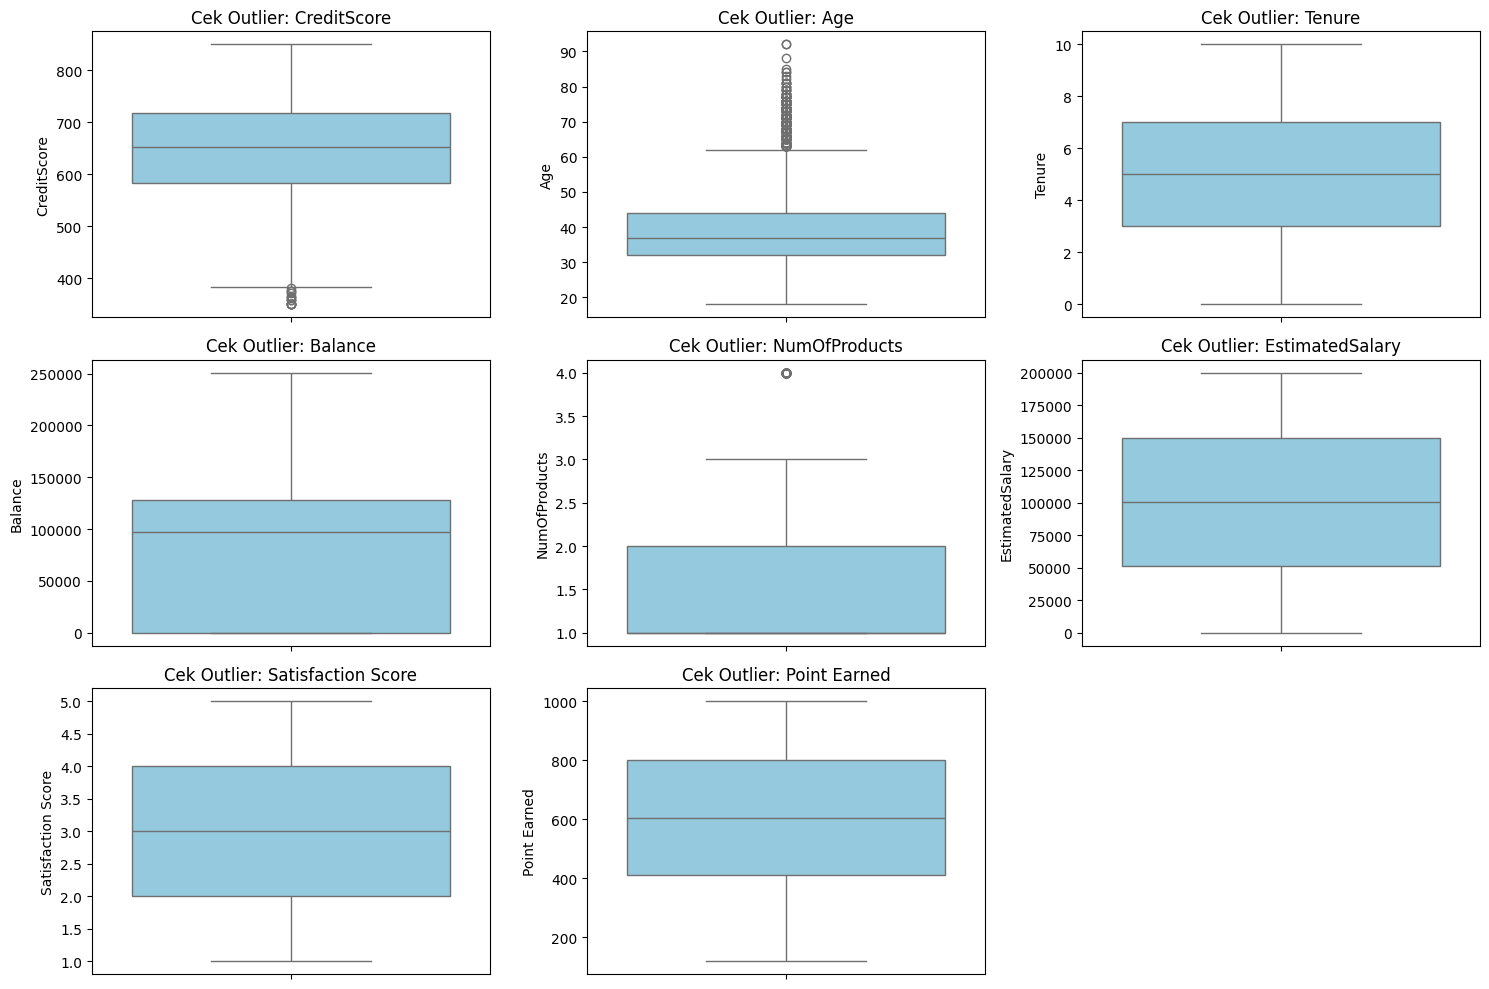

In [56]:
num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'Satisfaction Score', 'Point Earned']

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Cek Outlier: {col}')

plt.tight_layout()
plt.show()

In [57]:
print("=== ANALISIS OUTLIER (IQR) ===")
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    if len(outliers) > 0:
        print(f"Kolom {col}: Ada {len(outliers)} data outlier")
    else:
        print(f"Kolom {col}: Bersih (0 outlier)")

=== ANALISIS OUTLIER (IQR) ===
Kolom CreditScore: Ada 15 data outlier
Kolom Age: Ada 359 data outlier
Kolom Tenure: Bersih (0 outlier)
Kolom Balance: Bersih (0 outlier)
Kolom NumOfProducts: Ada 60 data outlier
Kolom EstimatedSalary: Bersih (0 outlier)
Kolom Satisfaction Score: Bersih (0 outlier)
Kolom Point Earned: Bersih (0 outlier)


In [58]:
missing_val = df.isnull().sum()
percent_missing = (missing_val * 100 / len(df))

In [59]:
cols_to_drop = percent_missing[percent_missing > 25].index.tolist()
cols_to_fix = percent_missing[(percent_missing > 0) & (percent_missing <= 25)].index.tolist()

In [60]:
print(f"Kolom yang di-drop (>25%): {cols_to_drop}")
print(f"Kolom yang di-isi (<25%): {cols_to_fix}")

Kolom yang di-drop (>25%): []
Kolom yang di-isi (<25%): []


In [61]:
df.drop(columns=cols_to_drop, inplace=True)

In [62]:
for col in cols_to_fix:
  #ceknumerikal
    if df[col].dtype in ['int64', 'float64']:
        # median
        df[col] = df[col].fillna(df[col].median())
    else:
        # modus
        df[col] = df[col].fillna(df[col].mode()[0])

In [63]:
print("\nSisa missing value:")
print(df.isnull().sum().sum())


Sisa missing value:
0


In [64]:
df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Satisfaction Score,Card Type,Point Earned
0,619,0,42,2,0.00,1,1,1,101348.88,1,2,DIAMOND,464
1,608,0,41,1,83807.86,1,0,1,112542.58,0,3,DIAMOND,456
2,502,0,42,8,159660.80,3,1,0,113931.57,1,3,DIAMOND,377
3,699,0,39,1,0.00,2,0,0,93826.63,0,5,GOLD,350
4,850,0,43,2,125510.82,1,1,1,79084.10,0,5,GOLD,425


In [65]:
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Satisfaction Score,Card Type,Point Earned
0,619,0,42,2,0.00,1,1,1,101348.88,1,2,DIAMOND,464
1,608,0,41,1,83807.86,1,0,1,112542.58,0,3,DIAMOND,456
2,502,0,42,8,159660.80,3,1,0,113931.57,1,3,DIAMOND,377
3,699,0,39,1,0.00,2,0,0,93826.63,0,5,GOLD,350
4,850,0,43,2,125510.82,1,1,1,79084.10,0,5,GOLD,425


In [66]:
df = pd.get_dummies(df, columns=['Card Type'], dtype=int)
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Satisfaction Score,Point Earned,Card Type_DIAMOND,Card Type_GOLD,Card Type_PLATINUM,Card Type_SILVER
0,619,0,42,2,0.00,1,1,1,101348.88,1,2,464,1,0,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,3,456,1,0,0,0
2,502,0,42,8,159660.80,3,1,0,113931.57,1,3,377,1,0,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,0,5,350,0,1,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,5,425,0,1,0,0


# Train Test Split

In [67]:
from sklearn.model_selection import train_test_split

X = df.drop('Exited', axis=1)
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Jumlah data latihan: {len(X_train)}")
print(f"Jumlah data ujian: {len(X_test)}")

Jumlah data latihan: 8000
Jumlah data ujian: 2000


In [68]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ML Modelling & Training

In [69]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [70]:
model = RandomForestClassifier(n_estimators=100, random_state=42)

In [71]:
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [72]:
y_pred = model.predict(X_test)

In [73]:
print("Akurasi Model:", accuracy_score(y_test, y_pred))
print("\nLaporan Klasifikasi:\n", classification_report(y_test, y_pred))

Akurasi Model: 0.8575

Laporan Klasifikasi:
               precision    recall  f1-score   support

           0       0.87      0.97      0.92      1607
           1       0.75      0.41      0.53       393

    accuracy                           0.86      2000
   macro avg       0.81      0.69      0.72      2000
weighted avg       0.85      0.86      0.84      2000

